# RF/FM Node Diagnostics

### Imports and Setup


In [1]:
import glob              # File pattern matching (e.g., finding all CSV files)
import os                # Operating system interface (file paths, directory operations)
import time              # Time measurement and delays
from datetime import datetime
import tracemalloc       # Memory allocation tracing (for performance profiling)
try:
    import psutil        # System resource monitoring (CPU, memory usage)
except ImportError:
    psutil = None 

import numpy as np       # Numerical operations, arrays, mathematical functions
import pandas as pd      # DataFrames, data manipulation, CSV handling
import matplotlib.pyplot as plt  # Plotting and visualization
import matplotlib.ticker as ticker  # Customizing axis ticks and labels

import ast               # Safely evaluate string literals (e.g., "[1,2,3]" -> list)
from tqdm import tqdm    # Progress bars for long-running loops

from dataclasses import dataclass  # Create structured data containers (e.g., NoiseFloorResult)
from typing import Optional, Dict
from scipy.ndimage import generic_filter  # Apply sliding window functions to arrays

In [2]:
"""
Centralized configuration for FM broadcast compliance monitoring.
All frequency estimation parameters defined in ONE place.
"""


@dataclass(frozen=True)
class FrequencyEstimationConfig:
    """Carrier-frequency estimation parameters."""
    
    # Band definition
    fm_start_mhz: float = 88.0
    fm_end_mhz: float = 108.0
    channel_spacing_mhz: float = 0.200  # FM broadcast channel spacing
    
    # Center frequency detection
    target_freq_mhz: Optional[float] = None  # Set per sweep segment
    search_bw_mhz: float = 1.5  # Search window around target
    spike_max_width_mhz: float = 0.050  # 50 kHz ceiling for DC spike
    
    # Spike detection thresholds (UNIFIED)
    min_spike_db: float = 8.0  # Minimum protrusion above baseline
    center_spike_threshold_db: float = 8.0  # MUST match min_spike_db
    guard_threshold_db: float = 8.0  # MUST match min_spike_db
    spike_thresh_db: float = 8.0  # MUST match min_spike_db
    
    # Guard bands
    dc_guard_mhz: float = 0.030
    center_extra_guard_mhz: float = 0.010
    carrier_guard_bins: int = 5
    fm_half_bw_mhz: float = 0.200
    
    # Noise floor estimation
    noise_q: float = 0.20
    window_mhz: float = 1.0
    carrier_threshold_db: float = 10.0
    
    # Clipping detection
    clipping_percentile: float = 99.0
    clipping_db_threshold: float = 1.0
    adc_ceiling_db: float = 0.0
    
    # Center spike removal (HackRF-specific)
    remove_center_spike: bool = True
    center_ref_inner_mhz: float = 0.020
    center_ref_outer_mhz: float = 0.250
    center_probe_mhz: float = 0.015
    center_anchor_mhz: float = 0.010
    center_shoulder_inner_mhz: float = 0.020
    center_shoulder_outer_mhz: float = 0.080
    center_shoulder_prominence_db: float = 5.0
    center_spike_max_half_width_mhz: float = 0.050  # FIXED: was 0.080
    center_symmetry_ratio_max: float = 2.5
    center_min_hot_bins: int = 1
    
    # Narrow spike masking
    remove_narrow_spikes: bool = True
    spike_window_mhz: float = 0.030
    max_spike_width_bins: int = 2
    spike_guard_bins: int = 1
    
    def validate(self) -> None:
        """Ensure threshold consistency."""
        thresholds = {
            'min_spike_db': self.min_spike_db,
            'center_spike_threshold_db': self.center_spike_threshold_db,
            'guard_threshold_db': self.guard_threshold_db,
            'spike_thresh_db': self.spike_thresh_db,
        }
        unique_values = set(thresholds.values())
        if len(unique_values) > 1:
            raise ValueError(
                f"Spike detection thresholds MUST be identical. Found: {thresholds}"
            )
        
        # Validate spike width consistency
        if self.center_spike_max_half_width_mhz > self.spike_max_width_mhz:
            raise ValueError(
                f"center_spike_max_half_width_mhz ({self.center_spike_max_half_width_mhz}) "
                f"must be <= spike_max_width_mhz ({self.spike_max_width_mhz})"
            )

@dataclass
class CalibrationState:
    """Traceable calibration metadata for compliance."""
    calibration_id: str
    calibration_date: datetime
    calibration_due_date: datetime
    frequency_standard: str  # e.g., "GPSDO", "Rubidium", "TCXO"
    frequency_standard_accuracy_ppb: float
    antenna_factor_db: float
    cable_loss_db: float
    receiver_gain_db: float
    reference_plane: str  # e.g., "Antenna Port", "Connector"
    calibration_certificate: str  # Path or ID
    
    def get_total_gain_correction_db(self) -> float:
        """Compute total gain correction for absolute power."""
        return self.antenna_factor_db - self.cable_loss_db + self.receiver_gain_db

@dataclass
class AssignedFrequency:
    """Regulatory broadcast frequency assignment."""
    station_call_sign: str
    assigned_frequency_mhz: float
    licensed_bandwidth_mhz: float
    licensed_power_dbm: float
    license_expiry: datetime
    regulatory_authority: str  # e.g., "CRC Colombia", "FCC USA"

# Global configuration instance (import everywhere)
DEFAULT_CONFIG = FrequencyEstimationConfig()

### Data Loading and Parsing

In [3]:
def load_node_csvs(
    root_pattern: str,
    *,
    exclude_basenames=None,
    read_csv_kwargs=None,
    show_progress: bool = True,
    sort_files: bool = False,
):
    """Load CSV files matching pattern into dictionary of DataFrames."""
    exclude = {
        os.path.splitext(os.path.basename(x))[0]
        for x in (exclude_basenames or [])
    }
    read_csv_kwargs = read_csv_kwargs or {}

    archivos_all = glob.glob(root_pattern)
    if sort_files:
        archivos_all.sort()

    # Generator instead of full list
    archivos_iter = (
        (path, os.path.splitext(os.path.basename(path))[0])
        for path in archivos_all
        if os.path.splitext(os.path.basename(path))[0] not in exclude
    )

    iterator = tqdm(archivos_iter, desc="Loading CSVs") if show_progress else archivos_iter

    datos_nodos = {}
    errors = []

    try:
        for archivo, nombre_nodo in iterator:
            try:
                datos_nodos[nombre_nodo] = pd.read_csv(archivo, **read_csv_kwargs)
            except (pd.errors.ParserError, FileNotFoundError, OSError) as e:
                error_msg = f"{type(e).__name__}: {e}"
                errors.append((archivo, error_msg))
                if show_progress:
                    tqdm.write(f"   {archivo}: {error_msg}")
    finally:
        if show_progress and hasattr(iterator, 'close'):
            iterator.close()

    archivos_cargados = list(datos_nodos.keys())
    return datos_nodos, archivos_cargados, errors


def parse_pxx_cell(pxx_raw):
    """Parse PSD data into 1D float array with comprehensive error handling."""
    
    # 1. NumPy fast path
    if isinstance(pxx_raw, np.ndarray):
        return pxx_raw.astype(float, copy=False).ravel()
    
    # 2. Sequence fast path  
    if isinstance(pxx_raw, (list, tuple)):
        return np.array(pxx_raw, dtype=float).ravel()
    
    # 3. Pandas Series
    if isinstance(pxx_raw, pd.Series):
        return pxx_raw.to_numpy(dtype=float).ravel()
    
    # 4. String parsing with fallbacks
    s = str(pxx_raw).strip()
    if not s:
        return np.array([], dtype=float)
    
    # Try bracket notation
    if s.startswith("[") and s.endswith("]"):
        body = s[1:-1].replace(",", " ").replace("nan", "NaN").replace("inf", "Inf")
        try:
            parts = body.split()
            return np.fromiter(map(float, parts), dtype=float, count=len(parts))
        except ValueError:
            pass
    
    # Safe fallback
    try:
        return np.asarray(ast.literal_eval(s), dtype=float).ravel()
    except Exception as e:
        raise ValueError(f"Cannot parse '{s[:30]}...': {e}") from e

###  Preprocessing Stage: Noise Floor Estimation

In [4]:
def to_db(pxx, *, scale="dB", eps=1e-12):
    # NOTE: caller must pass a float64 ndarray — no re-cast needed
    if scale == "linear":
        pxx_db = 10.0 * np.log10(np.maximum(pxx, eps))   # new array, fine
    elif scale == "dB":
        pxx_db = pxx.copy()   # copy only if we need to mutate below
    else:
        raise ValueError("scale must be 'dB' or 'linear'")

    non_finite = ~np.isfinite(pxx_db)
    if non_finite.any():
        pxx_db[non_finite] = np.nan   #  in-place, no extra allocation
    return pxx_db


def detect_center_spike(
    frequencies,
    pxx,
    *,
    scale="dB",
    target_freq=None,
    guard_bins=2,
    baseline_mode="median",
    baseline_q=0.2,
    threshold_db=6.0,
    eps=1e-12,
    return_arrays=False,          #  opt-in for large array payloads
):
    pxx = np.asarray(pxx, dtype=float).ravel()
    freqs = np.asarray(frequencies, dtype=float).ravel()
    if pxx.size == 0 or freqs.size != pxx.size:
        raise ValueError("frequencies and pxx must be same non-zero length")

    k0 = pxx.size // 2 if target_freq is None else int(np.argmin(np.abs(freqs - target_freq)))

    pxx_db = to_db(pxx, scale=scale, eps=eps)

    #  slice-based mask — no arange allocation
    mask = np.ones(pxx_db.size, dtype=bool)
    lo = max(0, k0 - int(guard_bins))
    hi = min(pxx_db.size, k0 + int(guard_bins) + 1)
    mask[lo:hi] = False
    if not mask.any():
        raise ValueError("guard_bins too large for PSD length")

    baseline_vals = pxx_db[mask]

    #  avoid nan-scan overhead on clean data
    has_nan = np.isnan(baseline_vals).any()
    if baseline_mode == "median":
        baseline_db = np.nanmedian(baseline_vals) if has_nan else np.median(baseline_vals)
    elif baseline_mode == "quantile":
        baseline_db = np.nanquantile(baseline_vals, baseline_q) if has_nan else np.quantile(baseline_vals, baseline_q)
    else:
        raise ValueError("baseline_mode must be 'median' or 'quantile'")

    center_db = pxx_db[k0]
    spike_db = center_db - baseline_db

    result = dict(
        index=k0,
        freq=freqs[k0],
        baseline_db=baseline_db,
        center_db=center_db,
        spike_db=float(spike_db),
        spike_ratio=10.0 ** (spike_db / 10.0),
        is_significant=bool(spike_db >= threshold_db),
    )
    if return_arrays:                   #  only pay the memory cost when needed
        result["pxx_db"] = pxx_db
        result["mask_baseline"] = mask
    return result

def estimate_noise_floor_db(pxx_db: np.ndarray, mask: np.ndarray | None = None, q: float = 0.2) -> float:
    """Noise floor estimate via low quantile (robust against carriers)."""
    vals = pxx_db[np.asarray(mask, dtype=bool)] if mask is not None else pxx_db
    if vals.size == 0:
        raise ValueError("No samples available for noise floor estimation — check mask.")
    return float(np.nanquantile(vals, q))

### Noise Floor Estimation

In [5]:

@dataclass
class NoiseFloorResult:
    floor_db:                 np.ndarray   # per-bin noise floor estimate (shape N)
    scalar_db:                float        # median of floor_db
    valid_mask:               np.ndarray   # bool (N,) — bins used in floor estimation
    clipping_flag:            bool         # suspicious clipping/compression
    dynamic_range_db:         float        # peak(cleaned PSD) - scalar floor

    clean_pxx_db:             np.ndarray   # PSD after center-spike cleanup
    center_spike_mask:        np.ndarray   # bins replaced/interpolated
    center_spike_flag:        bool         # True if a center spike was detected
    center_spike_width_mhz:   float        # total removed width
    center_guard_mask:        np.ndarray   # actual center-region mask used in floor fit
    narrow_spike_mask:        np.ndarray
    narrow_spike_local_median_db: np.ndarray


def _db_to_lin(db: np.ndarray) -> np.ndarray:
    return np.power(10.0, np.asarray(db, dtype=float) / 10.0)


def _lin_to_db(p: np.ndarray, floor: float = 1e-30) -> np.ndarray:
    return 10.0 * np.log10(np.maximum(np.asarray(p, dtype=float), floor))


def _nan_quantile(window: np.ndarray, q: float) -> float:
    finite = window[np.isfinite(window)]
    return float(np.quantile(finite, q)) if finite.size >= 3 else np.nan


def _interp_fill_segment_linear_power(
    x_mhz: np.ndarray,
    y_db: np.ndarray,
    lo: int,
    hi: int,
    *,
    fallback_db: float,
) -> None:
    """
    Replace y_db[lo:hi+1] by interpolation in linear power, then convert back to dB.
    """
    left = lo - 1
    while left >= 0 and not np.isfinite(y_db[left]):
        left -= 1

    right = hi + 1
    while right < y_db.size and not np.isfinite(y_db[right]):
        right += 1

    if left >= 0 and right < y_db.size:
        p_left = float(_db_to_lin(y_db[left]))
        p_right = float(_db_to_lin(y_db[right]))
        p_interp = np.interp(
            x_mhz[lo:hi + 1],
            [x_mhz[left], x_mhz[right]],
            [p_left, p_right],
        )
        y_db[lo:hi + 1] = _lin_to_db(p_interp)
    else:
        y_db[lo:hi + 1] = fallback_db


def _median3_nan(x: np.ndarray) -> np.ndarray:
    """
    Tiny 3-point median smoother used only for center-spike width expansion
    so one noisy dip does not prematurely stop the expansion.
    """
    y = np.asarray(x, dtype=float).copy()
    n = y.size
    if n < 3:
        return y

    out = y.copy()
    for i in range(1, n - 1):
        triplet = y[i - 1:i + 2]
        finite = triplet[np.isfinite(triplet)]
        out[i] = np.median(finite) if finite.size > 0 else np.nan
    return out


def _nan_median(window: np.ndarray) -> float:
    finite = window[np.isfinite(window)]
    return float(np.median(finite)) if finite.size >= 1 else np.nan


def _mask_narrow_spikes(
    clean_pxx_db: np.ndarray,
    valid_mask: np.ndarray,
    *,
    half_window_bins: int,
    spike_thresh_db: float,
    max_spike_width_bins: int,
    spike_guard_bins: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Detect narrow positive spikes relative to a local median baseline.

    A bin-run is marked as a narrow spike if:
      - it is currently valid
      - it exceeds the local median by spike_thresh_db
      - its contiguous width is <= max_spike_width_bins

    Returns
    -------
    spike_mask : np.ndarray of bool
        Bins to exclude from the floor fit.
    local_median_db : np.ndarray
        Local median baseline used for detection.
    """
    x = np.asarray(clean_pxx_db, dtype=float)
    valid = np.asarray(valid_mask, dtype=bool)

    if x.ndim != 1 or valid.ndim != 1 or x.size != valid.size:
        raise ValueError("clean_pxx_db and valid_mask must be 1-D arrays of equal length")

    n = x.size
    half_window_bins = int(max(1, half_window_bins))
    max_spike_width_bins = int(max(1, max_spike_width_bins))
    spike_guard_bins = int(max(0, spike_guard_bins))

    # Only valid bins contribute to the local baseline
    masked = np.where(valid, x, np.nan)

    local_median_db = generic_filter(
        masked,
        _nan_median,
        size=2 * half_window_bins + 1,
        mode="constant",
        cval=np.nan,
    )

    candidate = (
        valid
        & np.isfinite(local_median_db)
        & np.isfinite(x)
        & ((x - local_median_db) >= float(spike_thresh_db))
    )

    spike_mask = np.zeros(n, dtype=bool)
    idx = np.flatnonzero(candidate)

    if idx.size == 0:
        return spike_mask, local_median_db

    # Split into contiguous runs
    breaks = np.where(np.diff(idx) > 1)[0] + 1
    runs = np.split(idx, breaks)

    for run in runs:
        if run.size <= max_spike_width_bins:
            lo = max(0, int(run[0]) - spike_guard_bins)
            hi = min(n, int(run[-1]) + spike_guard_bins + 1)
            spike_mask[lo:hi] = True

    return spike_mask, local_median_db

def _estimate_and_remove_hackrf_center_spike(
    freqs_mhz: np.ndarray,
    pxx_db: np.ndarray,
    *,
    band_center_mhz: float,
    bin_res_mhz: float,
    q: float,
    center_spike_threshold_db: float,
    center_ref_inner_mhz: float,
    center_ref_outer_mhz: float,
    center_probe_mhz: float,
    center_anchor_mhz: float,
    center_shoulder_inner_mhz: float,
    center_shoulder_outer_mhz: float,
    center_shoulder_prominence_db: float,
    center_spike_max_half_width_mhz: float,
    center_symmetry_ratio_max: float,
    center_min_hot_bins: int,
) -> tuple[np.ndarray, np.ndarray, bool, float]:
    """
    HackRF-oriented DC center-spike detector with false-positive safeguards.

    Safeguards:
      1. Spike must be anchored very near true DC.
      2. Spike must exceed both ring-floor and local shoulders.
      3. Spike width must be approximately symmetric around DC.
      4. Removal width is capped.

    Returns:
      cleaned_pxx_db, spike_mask, spike_flag, total_removed_width_mhz
    """
    cleaned = np.asarray(pxx_db, dtype=float).copy()
    n = cleaned.size
    spike_mask = np.zeros(n, dtype=bool)

    dc_idx = int(np.argmin(np.abs(freqs_mhz - band_center_mhz)))

    ref_inner_bins = max(1, int(np.ceil(center_ref_inner_mhz / bin_res_mhz)))
    ref_outer_bins = max(ref_inner_bins + 1, int(np.ceil(center_ref_outer_mhz / bin_res_mhz)))
    probe_bins = max(1, int(np.ceil(center_probe_mhz / bin_res_mhz)))
    anchor_bins = max(1, int(np.ceil(center_anchor_mhz / bin_res_mhz)))
    shoulder_inner_bins = max(anchor_bins + 1, int(np.ceil(center_shoulder_inner_mhz / bin_res_mhz)))
    shoulder_outer_bins = max(shoulder_inner_bins + 1, int(np.ceil(center_shoulder_outer_mhz / bin_res_mhz)))
    max_half_bins = max(1, int(np.ceil(center_spike_max_half_width_mhz / bin_res_mhz)))

    # Reference ring excluding immediate center
    left_ref = cleaned[max(0, dc_idx - ref_outer_bins): max(0, dc_idx - ref_inner_bins)]
    right_ref = cleaned[min(n, dc_idx + ref_inner_bins + 1): min(n, dc_idx + ref_outer_bins + 1)]
    ref_vals = np.concatenate([left_ref, right_ref])
    ref_vals = ref_vals[np.isfinite(ref_vals)]

    if ref_vals.size < 8:
        return cleaned, spike_mask, False, 0.0

    ref_floor = float(np.quantile(ref_vals, q))
    threshold = ref_floor + float(center_spike_threshold_db)

    # Small probe around DC
    probe_lo = max(0, dc_idx - probe_bins)
    probe_hi = min(n, dc_idx + probe_bins + 1)
    probe_vals = cleaned[probe_lo:probe_hi]

    if probe_vals.size == 0 or not np.isfinite(probe_vals).any():
        return cleaned, spike_mask, False, 0.0

    # Core bins near DC that are above the ring threshold
    core_lo = max(0, dc_idx - anchor_bins)
    core_hi = min(n, dc_idx + anchor_bins + 1)
    core_vals = cleaned[core_lo:core_hi]
    core_hot = np.isfinite(core_vals) & (core_vals > threshold)
    hot_idx = np.where(core_hot)[0] + core_lo

    if hot_idx.size < center_min_hot_bins:
        return cleaned, spike_mask, False, 0.0

    # Choose seed from hot bins nearest DC, breaking ties by amplitude
    seed_candidates = hot_idx[np.argsort(np.abs(hot_idx - dc_idx))]
    seed_idx = int(seed_candidates[0])

    if abs(seed_idx - dc_idx) > anchor_bins:
        return cleaned, spike_mask, False, 0.0

    # Shoulder check: true center spike should stand above both nearby shoulders
    left_sh = cleaned[max(0, dc_idx - shoulder_outer_bins): max(0, dc_idx - shoulder_inner_bins)]
    right_sh = cleaned[min(n, dc_idx + shoulder_inner_bins + 1): min(n, dc_idx + shoulder_outer_bins + 1)]

    left_sh = left_sh[np.isfinite(left_sh)]
    right_sh = right_sh[np.isfinite(right_sh)]

    if left_sh.size < 3 or right_sh.size < 3:
        return cleaned, spike_mask, False, 0.0

    left_shoulder = float(np.median(left_sh))
    right_shoulder = float(np.median(right_sh))
    center_peak = float(np.nanmax(cleaned[hot_idx]))

    if (center_peak - max(left_shoulder, right_shoulder)) < center_shoulder_prominence_db:
        return cleaned, spike_mask, False, 0.0

    # Expand around the hot core using a tiny median-smoothed profile
    smooth = _median3_nan(cleaned)

    left = int(hot_idx.min())
    right = int(hot_idx.max())

    left_limit = max(0, dc_idx - max_half_bins)
    right_limit = min(n - 1, dc_idx + max_half_bins)

    while left - 1 >= left_limit:
        v = smooth[left - 1]
        if (not np.isfinite(v)) or (v <= threshold):
            break
        left -= 1

    while right + 1 <= right_limit:
        v = smooth[right + 1]
        if (not np.isfinite(v)) or (v <= threshold):
            break
        right += 1

    # Symmetry safeguard
    left_w = dc_idx - left
    right_w = right - dc_idx
    smaller = max(1, min(left_w, right_w))
    larger = max(left_w, right_w)

    if (larger / smaller) > center_symmetry_ratio_max:
        return cleaned, spike_mask, False, 0.0

    spike_mask[left:right + 1] = True

    _interp_fill_segment_linear_power(
        freqs_mhz,
        cleaned,
        left,
        right,
        fallback_db=ref_floor,
    )

    total_width_mhz = float(freqs_mhz[right] - freqs_mhz[left]) if right > left else 0.0
    return cleaned, spike_mask, True, total_width_mhz


def estimate_hackrf_noise_floor(
    freqs_mhz: np.ndarray,
    pxx_db: np.ndarray,
    *,
    # Minimum residual guard if no spike is detected
    dc_guard_mhz: float = 0.030,
    # Adaptive extra guard around detected spike
    center_extra_guard_mhz: float = 0.010,
    # Carrier rejection
    carrier_threshold_db: float = 10.0,
    carrier_guard_bins: int = 5,
    # Sliding quantile floor
    window_mhz: float = 1.0,
    q: float = 0.20,
    # Clipping suspicion
    clipping_percentile: float = 99.0,
    clipping_db_threshold: float = 1.0,
    adc_ceiling_db: float = 0.0,
    # Center-spike detection/removal
    remove_center_spike: bool = True,
    center_spike_threshold_db: float = 8.0,
    center_ref_inner_mhz: float = 0.020,
    center_ref_outer_mhz: float = 0.250,
    center_probe_mhz: float = 0.015,
    center_anchor_mhz: float = 0.010,
    center_shoulder_inner_mhz: float = 0.020,
    center_shoulder_outer_mhz: float = 0.080,
    center_shoulder_prominence_db: float = 5.0,
    center_spike_max_half_width_mhz: float = 0.080,
    center_symmetry_ratio_max: float = 2.5,
    center_min_hot_bins: int = 1,
    # Narrow-spike masking
    remove_narrow_spikes: bool = True,
    spike_window_mhz: float = 0.030,
    spike_thresh_db: float = 6.0,
    max_spike_width_bins: int = 2,
    spike_guard_bins: int = 1,
) -> NoiseFloorResult:
    """
    Tightened HackRF noise-floor estimator.

    Key changes vs the earlier version:
      - stronger false-positive safeguards for the center spike
      - interpolation in linear power
      - small fixed DC guard + adaptive center-spike guard
        so center-spike detection materially affects the floor fit
    """
    freqs = np.asarray(freqs_mhz, dtype=float).ravel()
    pxx = np.asarray(pxx_db, dtype=float).ravel()

    if freqs.size != pxx.size:
        raise ValueError("freqs_mhz and pxx_db must have the same length")

    n = pxx.size
    if n < 2:
        raise ValueError("At least 2 frequency bins are required.")
    if not np.isfinite(freqs).all():
        raise ValueError("freqs_mhz contains non-finite values")
    if not np.isfinite(pxx).any():
        raise ValueError("pxx_db contains no finite values")
    if not (0.0 < q < 1.0):
        raise ValueError("q must satisfy 0 < q < 1")
    if carrier_guard_bins < 0:
        raise ValueError("carrier_guard_bins must be >= 0")
    if dc_guard_mhz < 0 or center_extra_guard_mhz < 0:
        raise ValueError("dc_guard_mhz and center_extra_guard_mhz must be >= 0")
    if window_mhz <= 0:
        raise ValueError("window_mhz must be > 0")

    df = np.diff(freqs)
    if not np.isfinite(df).all():
        raise ValueError("freqs_mhz contains invalid spacing")
    if np.any(df <= 0):
        raise ValueError("freqs_mhz must be strictly increasing")

    bin_res_mhz = float(np.median(df))
    if bin_res_mhz <= 0:
        raise ValueError("Invalid frequency spacing")

    band_center_mhz = 0.5 * (freqs[0] + freqs[-1])

    # 1) Clipping suspicion
    top_val = float(np.nanmax(pxx))
    pct_val = float(np.nanpercentile(pxx, clipping_percentile))
    clipping_flag = bool(
        (top_val - pct_val) <= clipping_db_threshold
        and top_val >= (adc_ceiling_db - clipping_db_threshold)
    )

    # 2) Center-spike detection/removal
    clean_pxx = pxx.copy()
    center_spike_mask = np.zeros(n, dtype=bool)
    center_spike_flag = False
    center_spike_width_mhz = 0.0

    if remove_center_spike:
        clean_pxx, center_spike_mask, center_spike_flag, center_spike_width_mhz = (
            _estimate_and_remove_hackrf_center_spike(
                freqs,
                clean_pxx,
                band_center_mhz=band_center_mhz,
                bin_res_mhz=bin_res_mhz,
                q=q,
                center_spike_threshold_db=center_spike_threshold_db,
                center_ref_inner_mhz=center_ref_inner_mhz,
                center_ref_outer_mhz=center_ref_outer_mhz,
                center_probe_mhz=center_probe_mhz,
                center_anchor_mhz=center_anchor_mhz,
                center_shoulder_inner_mhz=center_shoulder_inner_mhz,
                center_shoulder_outer_mhz=center_shoulder_outer_mhz,
                center_shoulder_prominence_db=center_shoulder_prominence_db,
                center_spike_max_half_width_mhz=center_spike_max_half_width_mhz,
                center_symmetry_ratio_max=center_symmetry_ratio_max,
                center_min_hot_bins=center_min_hot_bins,
            )
        )

    # 3) Build valid mask using adaptive center guard
    valid = np.isfinite(clean_pxx)
    center_guard_mask = np.zeros(n, dtype=bool)

    min_guard_bins = int(np.ceil(dc_guard_mhz / bin_res_mhz))
    extra_guard_bins = int(np.ceil(center_extra_guard_mhz / bin_res_mhz))
    dc_idx = int(np.argmin(np.abs(freqs - band_center_mhz)))

    # Always apply a small mandatory DC guard
    lo0 = max(0, dc_idx - min_guard_bins)
    hi0 = min(n, dc_idx + min_guard_bins + 1)
    center_guard_mask[lo0:hi0] = True

    # If a spike was detected, add an adaptive guard around it
    if center_spike_flag and center_spike_mask.any():
        spike_idx = np.where(center_spike_mask)[0]
        lo1 = max(0, int(spike_idx[0]) - extra_guard_bins)
        hi1 = min(n, int(spike_idx[-1]) + extra_guard_bins + 1)
        center_guard_mask[lo1:hi1] = True

    valid &= ~center_guard_mask
    valid &= ~center_spike_mask

    # 3b) Narrow-spike masking (isolated thin spectral outliers)
    narrow_spike_mask = np.zeros(n, dtype=bool)
    narrow_spike_local_median_db = np.full(n, np.nan)

    if remove_narrow_spikes:
        spike_half_window_bins = max(
            max_spike_width_bins + 1,
            int(np.ceil((spike_window_mhz / bin_res_mhz) / 2)),
        )

        narrow_spike_mask, narrow_spike_local_median_db = _mask_narrow_spikes(
            clean_pxx,
            valid,
            half_window_bins=spike_half_window_bins,
            spike_thresh_db=spike_thresh_db,
            max_spike_width_bins=max_spike_width_bins,
            spike_guard_bins=spike_guard_bins,
        )

        valid &= ~narrow_spike_mask

    # 4) Two-pass carrier rejection
    for _ in range(2):
        if not valid.any():
            raise ValueError("All bins excluded — check center/guard settings and input data.")

        rough_floor = float(np.quantile(clean_pxx[valid], q))
        carrier_bins = np.where(valid & (clean_pxx > rough_floor + carrier_threshold_db))[0]

        for cb in carrier_bins:
            lo_c = max(0, cb - carrier_guard_bins)
            hi_c = min(n, cb + carrier_guard_bins + 1)
            valid[lo_c:hi_c] = False

    if valid.sum() < 10:
        raise ValueError(
            f"Too few clean bins ({valid.sum()}) after carrier rejection — "
            "reduce carrier_guard_bins or carrier_threshold_db."
        )

    # 5) Sliding-window local quantile
    half_w = max(1, int(np.ceil((window_mhz / bin_res_mhz) / 2)))
    masked_pxx = np.where(valid, clean_pxx, np.nan)

    floor_db = generic_filter(
        masked_pxx,
        _nan_quantile,
        size=2 * half_w + 1,
        mode="constant",
        cval=np.nan,
        extra_keywords={"q": q},
    )

    nan_mask = np.isnan(floor_db)
    if nan_mask.all():
        raise ValueError("Could not estimate noise floor; all local windows were empty.")

    if nan_mask.any():
        floor_db[nan_mask] = np.interp(
            freqs[nan_mask],
            freqs[~nan_mask],
            floor_db[~nan_mask],
        )

    scalar_db = float(np.median(floor_db))
    dynamic_range_db = float(np.nanmax(clean_pxx) - scalar_db)

    return NoiseFloorResult(
        floor_db=floor_db,
        scalar_db=scalar_db,
        valid_mask=valid,
        clipping_flag=clipping_flag,
        dynamic_range_db=dynamic_range_db,
        clean_pxx_db=clean_pxx,
        center_spike_mask=center_spike_mask,
        center_spike_flag=center_spike_flag,
        center_spike_width_mhz=center_spike_width_mhz,
        center_guard_mask=center_guard_mask,
        narrow_spike_mask=narrow_spike_mask,
        narrow_spike_local_median_db=narrow_spike_local_median_db,
    )

In [6]:
def plot_psd_nodes(
    datos_nodos: dict,
    *,
    row_plot: int,
    pxx_len: int,
    fm_start_mhz: float = 88.0,
    fm_end_mhz: float   = 108.0,
    center_freq_mhz: float = 98.0,
    pxx_scale: str  = "dB",
    noise_q: float  = 0.2,
    fm_half_bw_mhz: float = 0.200,
    guard_threshold_db: float = 6.0,
    ax_top_ylim: tuple[float, float] = (-27.0,  3.0),
    ax_bot_ylim: tuple[float, float] = ( -6.0, 27.0),
    xlim_half_mhz: float = 1.0,
    figsize: tuple[int, int] = (21, 14),
) -> tuple[plt.Figure, dict, dict]:
    """
    Parse, spike-detect, noise-floor-estimate and plot PSD for every node.

    Parameters
    ----------
    datos_nodos       : {node_name: DataFrame} — output of the CSV loader
    row_plot          : which row index to read from each DataFrame
    pxx_len           : expected FFT size (number of bins)
    fm_start/end_mhz  : band edges for the frequency axis
    center_freq_mhz   : alignment target for the bottom panel
    pxx_scale         : "dB" or "linear" — passed to detect_center_spike
    noise_q           : quantile for noise floor estimation
    fm_half_bw_mhz    : ±BW for the guard window around the center spike
    guard_threshold_db: spike detection threshold in dB
    ax_top/bot_ylim   : y-axis limits for each panel
    xlim_half_mhz     : half-width of the x zoom around center_freq_mhz
    figsize           : matplotlib figure size

    Returns
    -------
    fig                  : the matplotlib Figure
    pxx_centered_by_node : {node_name: ndarray} leveled PSD
    noise_floors         : {node_name: float} scalar noise floor per node
    """
    # ── Derived constants ───────────────────────────────────────────────────
    fm_band_mhz  = fm_end_mhz - fm_start_mhz
    bin_res_mhz  = fm_band_mhz / (pxx_len - 1)
    guard_bins   = int(np.ceil(fm_half_bw_mhz / bin_res_mhz)) + 1

    print(f"bin resolution : {bin_res_mhz * 1000:.3f} kHz/bin  |  GUARD_BINS: {guard_bins}")

    # ── Figure ──────────────────────────────────────────────────────────────
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize, sharex=True, constrained_layout=True
    )

    # ── Optimized cache (FIX #1: avoid dict overhead for single size) ───────
    _freqs_cache = None
    _cached_size = None
    
    pxx_centered_by_node: dict[str, np.ndarray] = {}
    noise_floors:         dict[str, float]       = {}

    # ── Main loop ───────────────────────────────────────────────────────────
    for nombre_nodo, df in datos_nodos.items():

        if "pxx" not in df.columns:
            print(f"  {nombre_nodo}: missing 'pxx' column — skipped")
            continue

        if not (0 <= row_plot < len(df)):
            print(f"  {nombre_nodo}: ROW_PLOT={row_plot} out of range — skipped")
            continue

        try:
            pxx = parse_pxx_cell(df["pxx"].iloc[row_plot])
        except (ValueError, TypeError, IndexError) as e:
            print(f"  {nombre_nodo}: failed to parse pxx: {e}")
            continue

        if pxx.size == 0:
            print(f"  {nombre_nodo}: empty pxx — skipped")
            continue

        if pxx.size != pxx_len:
            print(f"  ⚠️  {nombre_nodo}: pxx.size={pxx.size}, expected {pxx_len} — GUARD_BINS may be inaccurate")

        # ── Frequency axis (FIX #1: optimized cache) ────────────────────────
        if _cached_size != pxx.size:
            freqs_mhz = np.linspace(fm_start_mhz, fm_end_mhz, pxx.size)
            _freqs_cache = freqs_mhz
            _cached_size = pxx.size
        else:
            freqs_mhz = _freqs_cache

        # ── Spike detection ─────────────────────────────────────────────────
        res = detect_center_spike(
            freqs_mhz, pxx,
            scale=pxx_scale,
            target_freq=center_freq_mhz,
            guard_bins=guard_bins,
            baseline_mode="quantile",
            baseline_q=noise_q,
            threshold_db=guard_threshold_db,
            return_arrays=True,
        )

        # ── Noise floor ─────────────────────────────────────────────────────
        nf = estimate_hackrf_noise_floor(freqs_mhz, res["pxx_db"])

        if nf.clipping_flag:
            print(f"  ⚠️  {nombre_nodo}: ADC clipping suspected — noise floor unreliable")

        noise_floors[nombre_nodo] = nf.scalar_db

        print(
            f"{nombre_nodo}: "
            f"center={res['freq']:.3f} MHz | "
            f"noise_floor={nf.scalar_db:.2f} dB | "
            f"dynamic_range={nf.dynamic_range_db:.1f} dB | "
            f"spike={res['spike_db']:.2f} dB | "
            f"significant={res['is_significant']} | "
            f"clipping={nf.clipping_flag}"
        )

        # ── Plots ───────────────────────────────────────────────────────────
        ax_top.plot(freqs_mhz, res["pxx_db"], label=nombre_nodo, alpha=0.72)

        # FIX #2: reuse freqs_mhz calculation (avoid redundant array addition)
        freq_offset = center_freq_mhz - res["freq"]
        freqs_aligned_mhz = freqs_mhz + freq_offset
        
        pxx_centered = res["pxx_db"] - nf.floor_db
        pxx_centered_by_node[nombre_nodo] = pxx_centered

        ax_bot.plot(freqs_aligned_mhz, pxx_centered, label=nombre_nodo, alpha=0.7)

    # ── Axes formatting (FIX #3: optimize legend) ───────────────────────────
    xlim = (center_freq_mhz - xlim_half_mhz, center_freq_mhz + xlim_half_mhz)

    ax_top.set_title(f"Raw PSD — row {row_plot}")
    ax_top.set_ylabel("PSD [dB]")
    ax_top.set_xlim(xlim)
    ax_top.set_ylim(ax_top_ylim)
    ax_top.axhline(0, color="r", linestyle="--", linewidth=2)
    ax_top.grid(True, alpha=0.3)
    
    # FIX #3: faster legend rendering
    ax_top.legend(loc="upper right", fontsize="small", ncols=3, framealpha=0.9)

    ax_bot.set_title(f"Aligned to {center_freq_mhz} MHz — PSD relative to noise floor")
    ax_bot.set_xlabel("Frequency [MHz]")
    ax_bot.set_ylabel("PSD − noise floor [dB]")
    ax_bot.set_ylim(ax_bot_ylim)
    ax_bot.axhline(0, color="r", linestyle="--", linewidth=2)
    ax_bot.grid(True, alpha=0.3)

    plt.show()
    return fig, pxx_centered_by_node, noise_floors

In [7]:
def create_centered_datos_nodos(datos_nodos, pxx_centered_by_node):
    """
    Create a new datos_nodos dictionary with centered PSD values.
    
    Parameters
    ----------
    datos_nodos : dict
        Original datos_nodos with structure:
        {node_name: DataFrame with columns ['id', 'mac', 'campaign_id', 'pxx', 'start_freq_hz', ...]}
    pxx_centered_by_node : dict
        Centered PSD arrays:
        {node_name: numpy.ndarray of centered PSD values}
    
    Returns
    -------
    dict
        New dictionary with same structure but 'pxx' column replaced with centered values
    """
    import pandas as pd
    import numpy as np
    
    datos_nodos_ = {}
    
    for node_name, df in datos_nodos.items():
        # Create a copy of the DataFrame to avoid modifying the original
        df_new = df.copy()
        
        # Get the centered PSD array for this node
        if node_name not in pxx_centered_by_node:
            print(f"⚠️  Warning: {node_name} not found in pxx_centered_by_node, skipping...")
            continue
        
        centered_pxx = pxx_centered_by_node[node_name]
        
        # Check if we need to replicate the centered PSD for each row
        n_rows = len(df_new)
        
        # Method 1: If centered_pxx is a 1D array that should be the same for all rows
        if isinstance(centered_pxx, np.ndarray) and centered_pxx.ndim == 1:
            # Convert array to list format to match original structure
            centered_pxx_list = centered_pxx.tolist()
            
            # Assign the same centered PSD to all rows
            df_new['pxx'] = [centered_pxx_list] * n_rows
        
        # Method 2: If centered_pxx has one entry per row (2D array)
        elif isinstance(centered_pxx, np.ndarray) and centered_pxx.ndim == 2:
            if len(centered_pxx) != n_rows:
                print(f"⚠️  Warning: {node_name} has {n_rows} rows but centered_pxx has {len(centered_pxx)} entries")
            df_new['pxx'] = [row.tolist() for row in centered_pxx]
        
        else:
            print(f"⚠️  Warning: Unexpected centered_pxx format for {node_name}: {type(centered_pxx)}")
            continue
        
        datos_nodos_[node_name] = df_new
    
    print(f"\n✓ Created datos_nodos_ with {len(datos_nodos_)} nodes")
    
    return datos_nodos_

In [12]:
!pip install fm_compliance_config

ERROR: Could not find a version that satisfies the requirement fm_compliance_config (from versions: none)
ERROR: No matching distribution found for fm_compliance_config

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL A — Core algorithm: estimate_center_frequency()
# ═══════════════════════════════════════════════════════════════════════════════
from fm_compliance_config import DEFAULT_CONFIG
def estimate_center_frequency(
    freqs_mhz: np.ndarray,
    pxx_db: np.ndarray,
    *,
    target_freq_mhz: float | None = None,
    threshold_db = DEFAULT_CONFIG.min_spike_db,
    search_bw_mhz: float = 2.0,
    spike_max_width_mhz: float = 0.050,    # DC spike ≪ 50 kHz  (FM carrier ≥ 200 kHz)
    interp: str = "parabolic",             # "parabolic" | "gaussian" | "none"
) -> dict:
    """
    Estimate the HackRF-One DC-offset center-spike frequency with sub-bin accuracy.

    The HackRF One LO-leakage / I-Q DC-offset injects a narrow spike that sits at the
    *exact hardware tuning center frequency*.  This function locates that spike and
    returns its estimated frequency together with quality metrics useful for per-node
    sensor assessment.

    Distinguishing the DC spike from an FM broadcast carrier
    ─────────────────────────────────────────────────────────
    • DC spike   : ≤ 3 FFT bins wide  (< 30 kHz at 9.77 kHz/bin for 2048-point FFT)
    • FM carrier : ≥ 200 kHz mono,  ≥ 100 kHz stereo pilot, ≥ 38 kHz subcarrier
    The `spike_max_width_mhz` threshold (default 50 kHz) sits safely between the two.

    Parameters
    ──────────
    freqs_mhz        : 1-D array  — frequency axis in MHz (monotone increasing)
    pxx_db           : 1-D array  — PSD in dB, same length as freqs_mhz
    target_freq_mhz  : float, optional
        Nominal hardware center frequency (MHz).
        If None, the midpoint of the frequency axis is used.
    search_bw_mhz    : float
        ±half-bandwidth around target_freq_mhz to restrict the search  (default 2.0 MHz).
        Keep narrow enough to avoid confusing a strong FM station for the spike.
    spike_max_width_mhz : float
        Maximum 3-dB width (MHz) for the peak to be classified as a DC spike.
    min_spike_db     : float
        Minimum protrusion above the local baseline (dB) to accept the detection.
    interp           : str
        Sub-bin peak refinement method.
        "parabolic" — 3-point parabolic fit on log-power  (recommended, ±0.5-bin accuracy)
        "gaussian"  — 3-point Gaussian fit on log-power   (slightly smoother)
        "none"      — raw argmax bin, no interpolation

    Returns
    ───────
    dict with keys:
        freq_mhz         : float  — estimated center frequency (MHz)  ← main output
        spike_db         : float  — spike height above local baseline (dB)
                                    Large value → strong DC offset → more data corruption
        spike_width_mhz  : float  — 3-dB width of the detected spike (MHz)
                                    Narrow → clean ADC; Wide may indicate I-Q imbalance
        bin_index        : int    — FFT bin of the raw argmax
        subbin_shift     : float  — fractional-bin shift applied by interpolation
        deviation_mhz    : float  — freq_mhz − target_freq_mhz  (tuning error estimate)
        is_dc_spike      : bool   — True when peak passes the narrowness + amplitude tests
        confidence       : float  — heuristic score ∈ [0, 1];  ≥ 0.6 → reliable detection
        search_window    : tuple  — (lo_mhz, hi_mhz) search range actually used
    """
    freqs = np.asarray(freqs_mhz, dtype=np.float64).ravel()
    pxx   = np.asarray(pxx_db,   dtype=np.float64).ravel()

    if freqs.size != pxx.size or freqs.size < 5:
        raise ValueError("freqs_mhz and pxx_db must be the same length and contain ≥ 5 samples.")

    # ── 1. Search window ──────────────────────────────────────────────────────
    fc = float(target_freq_mhz) if target_freq_mhz is not None else float(freqs[freqs.size // 2])
    lo_mhz = fc - float(search_bw_mhz)
    hi_mhz = fc + float(search_bw_mhz)

    win_mask = (freqs >= lo_mhz) & (freqs <= hi_mhz)
    n_win = int(win_mask.sum())
    if n_win < 5:
        raise ValueError(
            f"Search window [{lo_mhz:.3f}, {hi_mhz:.3f}] MHz covers only {n_win} bins. "
            "Increase search_bw_mhz or verify the frequency axis."
        )

    win_idx  = np.where(win_mask)[0]
    pxx_win  = pxx[win_mask]
    freq_win = freqs[win_mask]

    # ── 2. Coarse peak (argmax inside window) ─────────────────────────────────
    peak_local  = int(np.nanargmax(pxx_win))
    peak_global = int(win_idx[peak_local])          # global bin index
    peak_db     = float(pxx[peak_global])

    # ── 3. Local baseline  (exclude ±spike_max_width_mhz guard around peak) ──
    bin_res_mhz  = float(np.median(np.diff(freqs)))
    half_guard   = max(1, int(np.ceil(float(spike_max_width_mhz) / bin_res_mhz)))

    lo_g = max(0, peak_global - half_guard)
    hi_g = min(freqs.size, peak_global + half_guard + 1)

    # Build baseline from the window, excluding the guard region
    baseline_global_mask = win_mask.copy()
    baseline_global_mask[lo_g:hi_g] = False
    baseline_vals = pxx[baseline_global_mask]

    if baseline_vals.size < 3:                      # window too small — fallback to full window
        baseline_vals = pxx_win

    local_baseline = float(np.nanmedian(baseline_vals))
    spike_db       = float(peak_db - local_baseline)

    # ── 4. Sub-bin interpolation ──────────────────────────────────────────────
    delta = 0.0

    if interp == "parabolic" and 1 <= peak_global <= freqs.size - 2:
        y0, y1, y2 = pxx[peak_global - 1], pxx[peak_global], pxx[peak_global + 1]
        denom = (y0 - 2.0 * y1 + y2)
        if np.isfinite(denom) and abs(denom) > 1e-9:
            delta = float(np.clip(0.5 * (y0 - y2) / denom, -1.0, 1.0))

    elif interp == "gaussian" and 1 <= peak_global <= freqs.size - 2:
        # Gaussian fit on log-power: δ = (ln y₀ − ln y₂) / (2·ln y₀ − 4·ln y₁ + 2·ln y₂)
        eps = 1e-30
        ln0 = np.log(max(pxx[peak_global - 1] - local_baseline + eps, eps))
        ln1 = np.log(max(pxx[peak_global]     - local_baseline + eps, eps))
        ln2 = np.log(max(pxx[peak_global + 1] - local_baseline + eps, eps))
        denom = 2.0 * ln0 - 4.0 * ln1 + 2.0 * ln2
        if abs(denom) > 1e-9:
            delta = float(np.clip((ln0 - ln2) / denom, -1.0, 1.0))

    freq_est = float(freqs[peak_global]) + delta * bin_res_mhz

    # ── 5. 3-dB width measurement ─────────────────────────────────────────────
    threshold_3db = peak_db - 3.0

    left_bin  = peak_global
    right_bin = peak_global

    while left_bin > win_idx[0]  and pxx[left_bin  - 1] > threshold_3db:
        left_bin  -= 1
    while right_bin < win_idx[-1] and pxx[right_bin + 1] > threshold_3db:
        right_bin += 1

    width_mhz = float(freqs[right_bin] - freqs[left_bin])

    # ── 6. Classification: DC spike vs. FM broadcast ──────────────────────────
    is_dc_spike = (width_mhz <= float(spike_max_width_mhz)) and (spike_db >= float(min_spike_db))

    # ── 7. Confidence score ∈ [0, 1] ─────────────────────────────────────────
    # Amplitude component (saturates at 30 dB protrusion)
    amp_score    = float(np.clip(spike_db / 30.0, 0.0, 1.0))
    # Narrowness component (relative to max allowed width)
    narrow_score = float(np.clip(1.0 - width_mhz / float(spike_max_width_mhz), 0.0, 1.0))
    confidence   = 0.60 * amp_score + 0.40 * narrow_score
    if not is_dc_spike:
        confidence *= 0.25     # penalise detections that fail classification

    return dict(
        freq_mhz        = freq_est,
        spike_db        = spike_db,
        spike_width_mhz = width_mhz,
        bin_index       = peak_global,
        subbin_shift    = delta,
        deviation_mhz   = freq_est - fc,
        is_dc_spike     = is_dc_spike,
        confidence      = confidence,
        search_window   = (lo_mhz, hi_mhz),
    )


# ═══════════════════════════════════════════════════════════════════════════════
# CELL B — Quality assessment wrapper: assess_center_frequency_quality()
# ───────────────────────────────────────────────────────────────────────────────
# Insert as a new cell after CELL A above.
# ═══════════════════════════════════════════════════════════════════════════════

def assess_center_frequency_quality(
    datos_nodos: dict,
    *,
    fm_start_mhz: float        = 88.0,
    fm_end_mhz: float          = 108.0,
    target_freq_mhz: float     = 107.9,   # nominal hardware center (tune freq)
    search_bw_mhz: float       = 2.0,
    spike_max_width_mhz: float = 0.050,
    min_spike_db: float        = 8.0,
    max_rows: int | None       = None,
    show_plot: bool            = True,
    figsize: tuple             = (20, 6),
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run `estimate_center_frequency` across every row and node, then produce a
    per-node quality summary table and diagnostic plots.

    This function evaluates each sensor on three orthogonal quality axes:

        1. Tuning accuracy  — |deviation_mhz|  (smaller → better)
           How precisely the node's LO centres on the commanded frequency.

        2. DC-spike severity — spike_db  (smaller → less I-Q corruption)
           A large DC spike implies a strong I-Q offset that corrupts the bins
           around the center frequency.

        3. Detection reliability — confidence ∈ [0,1]  (larger → more reliable)
           Combines amplitude and narrowness of the detected spike.

    Parameters
    ──────────
    datos_nodos         : {node_name: DataFrame}  from load_node_csvs()
    fm_start/end_mhz    : FM band edges used to reconstruct the frequency axis
    target_freq_mhz     : nominal hardware center (commanded tuning frequency, MHz)
    search_bw_mhz       : ±search half-bandwidth around target (MHz)
    spike_max_width_mhz : max 3-dB width for DC-spike classification (MHz)
    min_spike_db        : minimum protrusion for a valid detection (dB)
    max_rows            : if set, process only the first N rows per node (speeds up large datasets)
    show_plot           : whether to render the diagnostic figure
    figsize             : matplotlib figure size

    Returns
    ───────
    df_raw   : pd.DataFrame — one row per (node, measurement row) with all per-row metrics
    df_summary : pd.DataFrame — per-node aggregated statistics
    """
    records = []

    for nombre_nodo, df in tqdm(datos_nodos.items(), desc="Estimating center freq"):
        if "pxx" not in df.columns:
            print(f"  {nombre_nodo}: missing 'pxx' column — skipped")
            continue

        n_rows = len(df) if max_rows is None else min(len(df), int(max_rows))
        node_label = nombre_nodo.split("/")[-1]

        for row in range(n_rows):
            try:
                pxx = parse_pxx_cell(df["pxx"].iloc[row])
                if pxx.size == 0:
                    continue

                freqs_mhz = np.linspace(fm_start_mhz, fm_end_mhz, pxx.size)
                pxx_db    = to_db(pxx, scale="dB")   # assumes data already in dB

                res = estimate_center_frequency(
                    freqs_mhz, pxx_db,
                    target_freq_mhz     = target_freq_mhz,
                    search_bw_mhz       = search_bw_mhz,
                    spike_max_width_mhz = spike_max_width_mhz,
                    min_spike_db        = min_spike_db,
                )

                records.append({
                    "node"            : node_label,
                    "row"             : row,
                    "freq_mhz"        : res["freq_mhz"],
                    "spike_db"        : res["spike_db"],
                    "spike_width_khz" : res["spike_width_mhz"] * 1e3,
                    "deviation_khz"   : res["deviation_mhz"]   * 1e3,
                    "is_dc_spike"     : res["is_dc_spike"],
                    "confidence"      : res["confidence"],
                })

            except Exception:
                pass   # skip rows that cannot be parsed / are too short

    if not records:
        print("⚠️  No valid rows processed — check datos_nodos and target_freq_mhz.")
        return pd.DataFrame(), pd.DataFrame()

    df_raw = pd.DataFrame(records)

    # ── Per-node summary table ────────────────────────────────────────────────
    df_summary = (
        df_raw.groupby("node", sort=True)
        .agg(
            n_rows          = ("row",              "count"),
            n_dc_spikes     = ("is_dc_spike",      "sum"),
            freq_mean_mhz   = ("freq_mhz",         "mean"),
            freq_std_mhz    = ("freq_mhz",         "std"),
            dev_mean_khz    = ("deviation_khz",    "mean"),
            dev_std_khz     = ("deviation_khz",    "std"),
            dev_abs_max_khz = ("deviation_khz",    lambda x: x.abs().max()),
            spike_mean_db   = ("spike_db",         "mean"),
            spike_std_db    = ("spike_db",         "std"),
            width_mean_khz  = ("spike_width_khz",  "mean"),
            conf_mean       = ("confidence",       "mean"),
        )
        .reset_index()
    )

    df_summary["detection_rate_%"] = (
        100.0 * df_summary["n_dc_spikes"] / df_summary["n_rows"]
    ).round(1)

    # Quality ranking: penalise large |deviation|, large spike, low confidence
    # Each component normalised to [0, 1]; lower score = better sensor
    eps = 1e-9
    dev_score   = (df_summary["dev_abs_max_khz"]  / (df_summary["dev_abs_max_khz"].max()  + eps))
    spike_score = (df_summary["spike_mean_db"]    / (df_summary["spike_mean_db"].max()    + eps))
    conf_score  = 1.0 - (df_summary["conf_mean"]  / (df_summary["conf_mean"].max()        + eps))
    df_summary["quality_score"] = (0.40 * dev_score + 0.40 * spike_score + 0.20 * conf_score).round(4)
    # → smaller quality_score = BETTER sensor

    df_summary = df_summary.sort_values("quality_score").reset_index(drop=True)
    df_summary.insert(0, "rank", range(1, len(df_summary) + 1))
    
    return df_raw, df_summary


ModuleNotFoundError: No module named 'fm_compliance_config'

### Loading Loop

In [8]:
# =============================================================================
# 1. CONFIGURATION & PARAMETERS
# =============================================================================

ROOT_PATTERN = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"

EXCLUDE_BASENAME  = {
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}

datos_nodos, archivos, errors = load_node_csvs(
    ROOT_PATTERN,
    exclude_basenames=EXCLUDE_BASENAME,
    show_progress=True,
)

print(f"Loaded {len(datos_nodos)} nodes from {len(archivos)} files.")
if errors:
    print("Errors:")
    for f, msg in errors:
        print(f"  {f}: {msg}")

## ── Infer true FFT size from the first valid row ────────────────────────────

ROW_PLOT = 0
global_min = 103

_first_valid = next(
    (df for df in datos_nodos.values() if "pxx" in df.columns and len(df) > ROW_PLOT),
    None
)
if _first_valid is None:
    raise RuntimeError("No valid node found to infer FFT size.")

# Node organization (sorted for legend consistency)
NODE_NAMES  = sorted(datos_nodos.keys(), key=lambda x: x.split('/')[-1])
N_NODES     = len(NODE_NAMES)
NODE_LABELS = [n.split('/')[-1] for n in NODE_NAMES]

# PSD histogram binning strategy
pxx_len = parse_pxx_cell(_first_valid["pxx"].iloc[ROW_PLOT]).size  # Expected PSD array length

# Calculate N_BINS using average of Sturges-like and sqrt heuristics
N_BINS = int(np.ceil((np.log2(pxx_len) + np.sqrt(pxx_len)) / 2))

# Global value range for consistent histogram comparison across nodes
# Assumption: PSD values are in dB scale 
GLOBAL_RANGE = (-27, 6)  # (min_dB, max_dB)

# Pre-allocate shared bin edges so every node uses the same grid
bin_edges   = np.linspace(GLOBAL_RANGE[0], GLOBAL_RANGE[1], N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # For plotting

pxx_node = {}

for nombre_nodo, df in datos_nodos.items():
    if "pxx" not in df.columns:
        print(f" {nombre_nodo}: missing 'pxx' column")
        continue

    pxx = None
    for row in (0, global_min):
        try:
            candidate = parse_pxx_cell(df["pxx"].iloc[row])
            if candidate.size > 0:
                pxx = candidate
                break  # stop at first valid parse
        except Exception as e:
            print(f" {nombre_nodo}: failed to parse pxx at row {row} ({type(e).__name__}: {e})")

    if pxx is None or pxx.size == 0:
        print(f" {nombre_nodo}: empty pxx")
        continue

    # Placeholder RF axis 
    freqs_mhz = np.linspace(88.0, 108.0, pxx.size, endpoint=True)

    # Store both PSD and frequency axis for clarity
    pxx_node[nombre_nodo] = {
    "freqs_mhz": freqs_mhz,
    "pxx": pxx
}

Loading CSVs: 10it [00:11,  1.15s/it]Loaded 10 nodes from 10 files.



### Diagnostics for similarity of PSD distributions across nodes


This NB includes robust CSV loading, pxx parsing from heterogeneous formats, histogram-based PSD diagnostics, correlation-based node similarity, mutual-information ranking, center-spike checks, local noise-floor estimation, clipping flags, and before/after normalization comparisons. For screening, bad nodes or identifying anomalous sensors are detected. Ranking shows whether one node looks unusual relative to the others.

### Preprocessing Stage

#### *Noise floor*

bin resolution : 0.610 kHz/bin  |  GUARD_BINS: 329
Node2-Bogota: center=98.500 MHz | noise_floor=-22.93 dB | dynamic_range=37.7 dB | spike=28.77 dB | significant=True | clipping=False
Node9-Funza: center=98.500 MHz | noise_floor=-22.22 dB | dynamic_range=29.9 dB | spike=26.58 dB | significant=True | clipping=False
Node4-Bogota: center=98.500 MHz | noise_floor=-23.25 dB | dynamic_range=37.6 dB | spike=20.20 dB | significant=True | clipping=False
Node10-Bogota: center=98.500 MHz | noise_floor=-23.02 dB | dynamic_range=29.7 dB | spike=24.87 dB | significant=True | clipping=False
Node7-Bogota: center=98.500 MHz | noise_floor=-22.72 dB | dynamic_range=36.9 dB | spike=26.89 dB | significant=True | clipping=False
Node1-Bogota: center=98.500 MHz | noise_floor=-23.18 dB | dynamic_range=34.2 dB | spike=26.34 dB | significant=True | clipping=False
Node8-Bogota: center=98.500 MHz | noise_floor=-23.46 dB | dynamic_range=43.3 dB | spike=21.49 dB | significant=True | clipping=False
Node6-Bogota: cent

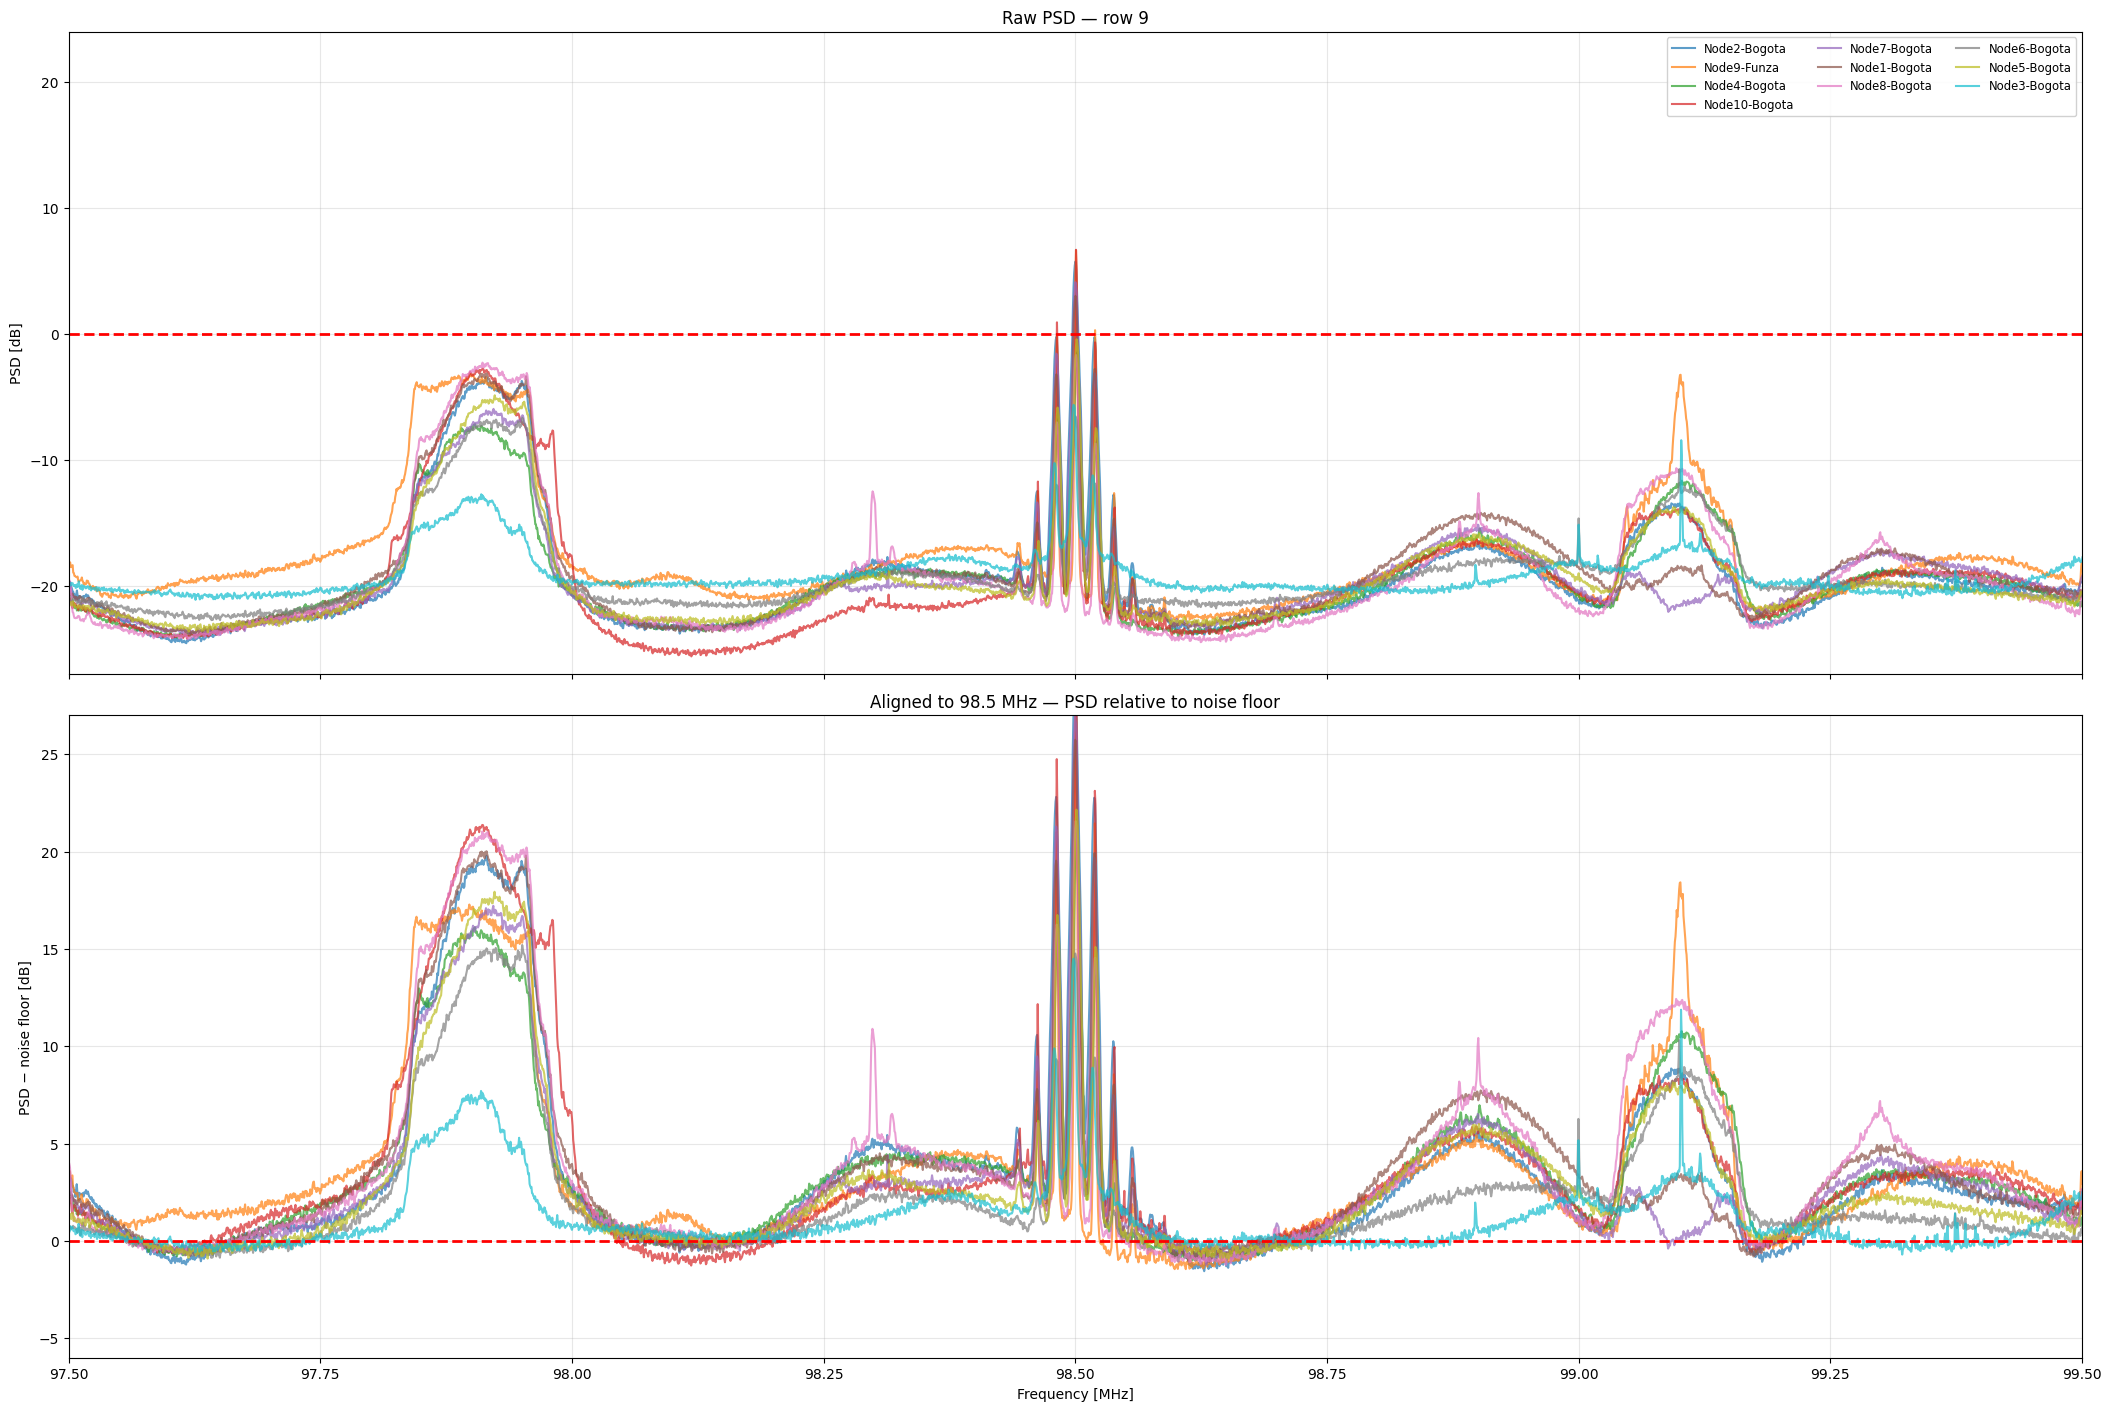


✓ Created datos_nodos_ with 10 nodes


In [9]:
F0 = 98.5

fig, pxx_centered_by_node, noise_floors = plot_psd_nodes(
    datos_nodos,
    row_plot        = 9,
    pxx_len         = pxx_len,
    center_freq_mhz = F0,
    noise_q         = 0.15,
    ax_top_ylim     = (-27, 24),
)

datos_nodos_ = create_centered_datos_nodos(datos_nodos, pxx_centered_by_node)

### Spectral Parameter Estimation Quality

#### *Center Frequency*

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Center Frequency Estimation
# ───────────────────────────────────────────────────────────────────────────────

# Adjust target_freq_mhz to the commanded tuning center of your HackRF sweep.
# For the FM-band campaign (88–108 MHz scanned in segments) you may need to call
# this once per tuning step.  

cf_raw, cf_summary = assess_center_frequency_quality(
    datos_nodos,
    fm_start_mhz        = 88.0,
    fm_end_mhz          = 108.0,
    target_freq_mhz     = F0,   # ← match center_freq_mhz used in plot_psd_nodes
    search_bw_mhz       = 1.5,     # ± 1.5 MHz — wide enough to tolerate tuning drift
    spike_max_width_mhz = 0.050,   # 50 kHz ceiling for DC-spike classification
    min_spike_db        = 8.0,     # 8 dB minimum protrusion
    max_rows            = None,    # None = all rows; set e.g. 50 for a quick preview
    show_plot           = False,
)

# Display the ranked summary table
cf_summary

Estimating center freq: 100%|██████████| 10/10 [00:11<00:00,  1.17s/it]


,rank,node,n_rows,n_dc_spikes,freq_mean_mhz,freq_std_mhz,dev_mean_khz,dev_std_khz,dev_abs_max_khz,spike_mean_db,spike_std_db,width_mean_khz,conf_mean,detection_rate_%,quality_score
0,1,Node8-Bogota,23,20,99.292341,0.940235,792.341237,940.234660,1401.328344,23.820719,4.245850,16.320768,0.710553,87.0,0.6690
1,2,Node5-Bogota,105,63,98.534963,0.823847,34.963475,823.846510,1460.229118,18.206569,3.038369,31.843885,0.465779,60.0,0.6778
2,3,Node1-Bogota,105,56,98.235431,0.623279,-264.569470,623.279275,1400.050865,19.319097,3.122884,38.453322,0.429445,53.3,0.6801
3,4,Node2-Bogota,105,70,98.309041,0.564607,-190.958612,564.607338,1400.161117,21.590152,3.510771,31.524167,0.537849,66.7,0.6811
4,5,Node9-Funza,105,51,98.097074,0.910723,-402.926360,910.722670,1406.550328,19.725096,3.321632,46.190491,0.412278,48.6,0.6893
5,6,Node7-Bogota,105,63,99.234414,0.783221,734.413728,783.221141,1477.316939,19.818594,3.682519,36.296681,0.495175,60.0,0.6925
6,7,Node10-Bogota,104,56,98.364803,0.762654,-135.197069,762.653748,1401.702709,21.207347,3.190992,39.603635,0.450876,53.8,0.6951
7,8,Node4-Bogota,105,46,99.767311,0.466815,1267.310612,466.814687,1407.545506,20.859591,4.056297,48.178554,0.401880,43.8,0.7030
8,9,Node6-Bogota,105,105,99.999444,0.000023,1499.444462,0.022770,1499.478790,34.848618,0.494436,0.360409,0.997117,100.0,0.7477
9,10,Node3-Bogota,105,105,99.999450,0.000022,1499.450293,0.022143,1499.478534,40.087672,0.526733,0.435979,0.996512,100.0,0.8001


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>